# Crawling Data NO2


### daerah dengan memberi shape kotak didaerah yang ingin ambil datanya.
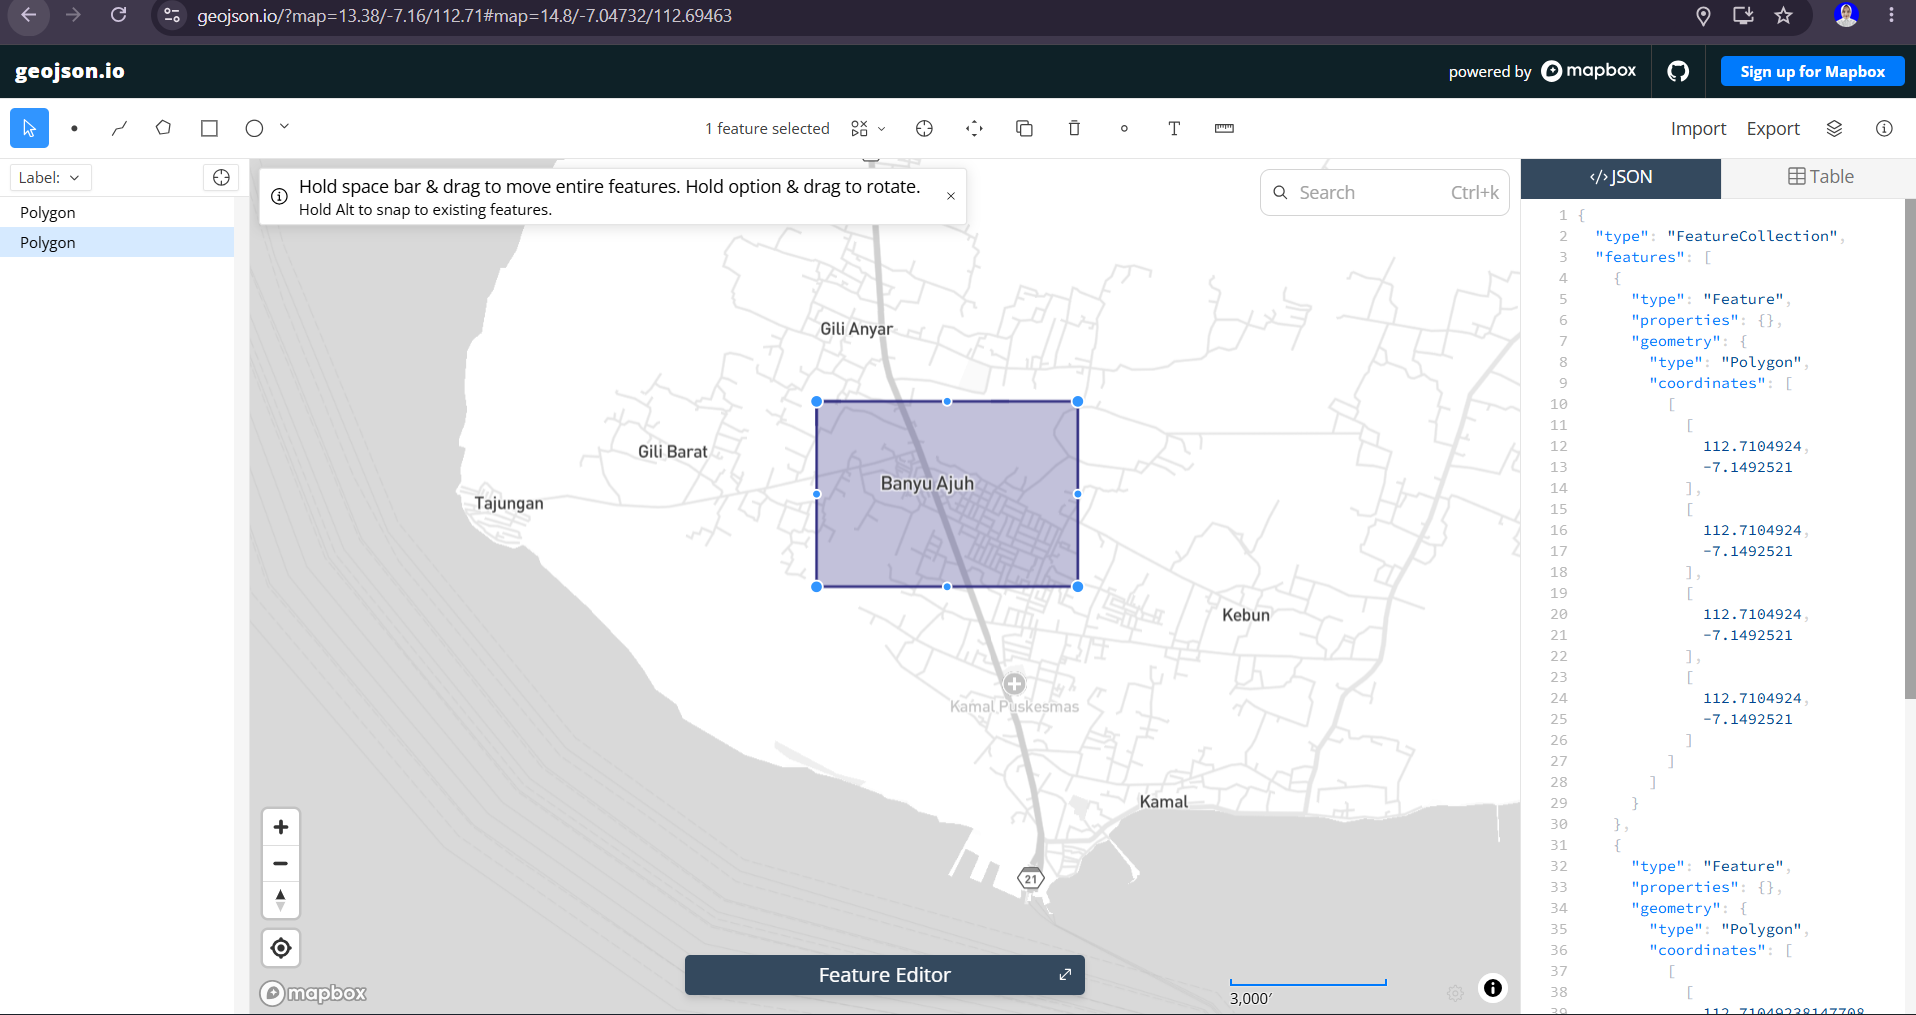


### status pengambilan data
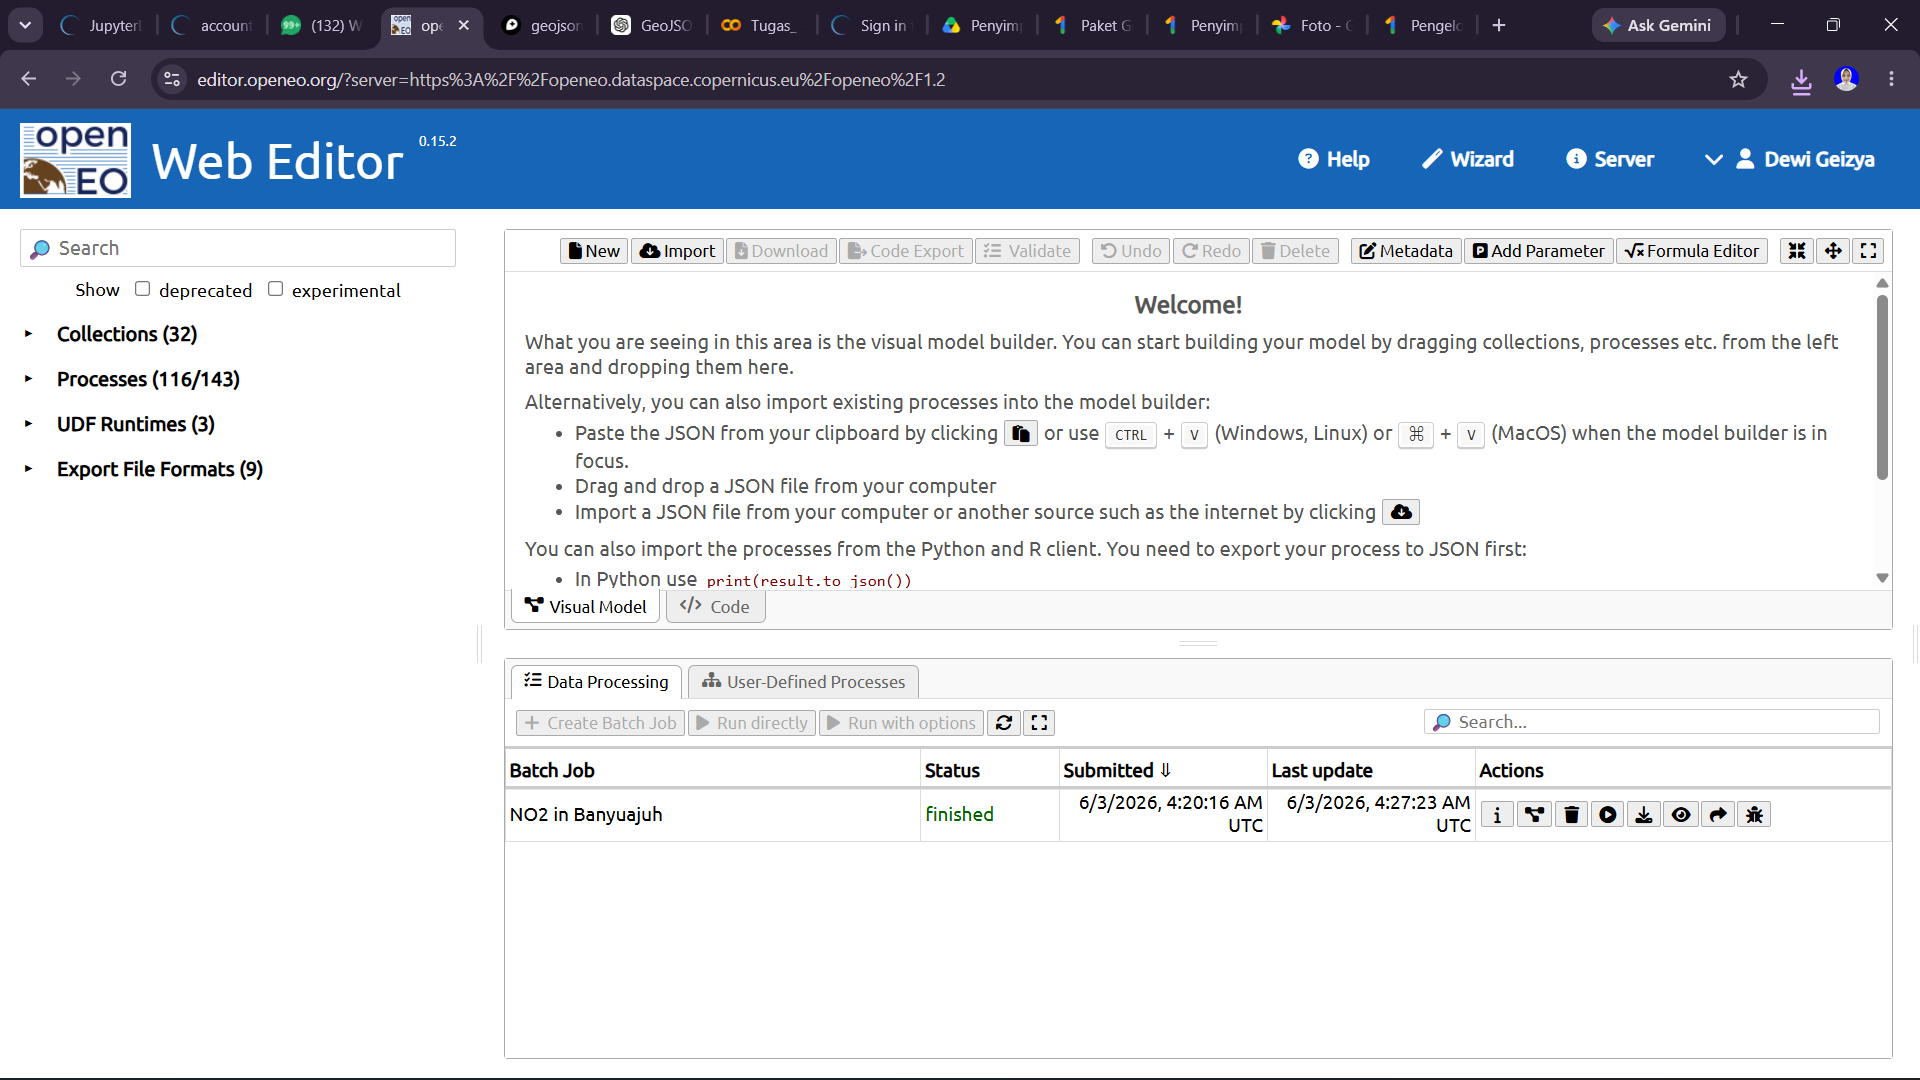

In [1]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.3 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [7]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=XHLL-AUGL 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


In [9]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.71049238147708, -7.149252064509284],
            [112.72430960667839, -7.149254678424455],
            [112.72430960480892, -7.158983341641246],
            [112.71048649105728, -7.158988519657072],
            [112.71049238147708, -7.149252064509284]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2025-10-01"],
    spatial_extent={
        "west": 112.71048649105728,
        "south": -7.158988519657072,
        "east": 112.72430960667839,
        "north": -7.149252064509284
    },
    bands=["NO2"],
)

# Agregasi temporal harian
s5p_no2_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial pada AOI
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)
job = s5post.execute_batch(
    title="NO2 in Banyuajuh",
    outputfile="NO2Banyuajuh.nc"
)

0:00:00 Job 'j-2606030420164f7280ebe09a5c754922': send 'start'
0:00:23 Job 'j-2606030420164f7280ebe09a5c754922': queued (progress 0%)
0:00:29 Job 'j-2606030420164f7280ebe09a5c754922': queued (progress 0%)
0:00:35 Job 'j-2606030420164f7280ebe09a5c754922': queued (progress 0%)
0:00:43 Job 'j-2606030420164f7280ebe09a5c754922': queued (progress 0%)
0:00:54 Job 'j-2606030420164f7280ebe09a5c754922': queued (progress 0%)
0:01:06 Job 'j-2606030420164f7280ebe09a5c754922': running (progress N/A)
0:01:21 Job 'j-2606030420164f7280ebe09a5c754922': running (progress N/A)
0:01:41 Job 'j-2606030420164f7280ebe09a5c754922': running (progress N/A)
0:02:05 Job 'j-2606030420164f7280ebe09a5c754922': running (progress N/A)
0:02:35 Job 'j-2606030420164f7280ebe09a5c754922': running (progress N/A)
0:03:13 Job 'j-2606030420164f7280ebe09a5c754922': running (progress N/A)
0:03:59 Job 'j-2606030420164f7280ebe09a5c754922': running (progress N/A)
0:04:58 Job 'j-2606030420164f7280ebe09a5c754922': running (progress N/A

In [22]:
from google.colab import files

uploaded = files.upload()

Saving openEO.nc to openEO.nc


In [23]:
!pip install netCDF4 -q

import netCDF4

ds = netCDF4.Dataset("openEO.nc")

print("Variabel dalam file:")
print(ds.variables.keys())

Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])


In [24]:
import netCDF4
import pandas as pd
import numpy as np

# ==========================
# BACA FILE NETCDF
# ==========================
file_path = "openEO.nc"

ds = netCDF4.Dataset(file_path)

# Lihat variabel yang tersedia
print("Variabel tersedia:")
print(ds.variables.keys())

# ==========================
# AMBIL DATA NO2
# ==========================
no2 = ds.variables["NO2"][:]

print("\nShape NO2:")
print(no2.shape)

# Ubah menjadi 1 dimensi
no2_values = np.array(no2).flatten()

# ==========================
# AMBIL DATA WAKTU
# ==========================
time = ds.variables["t"][:]

try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)

    # Ubah ke string agar aman untuk semua format NetCDF
    dates = [str(d)[:10] for d in dates]

except Exception as e:
    print("Gagal konversi tanggal:", e)

    # Jika gagal, gunakan indeks
    dates = list(range(len(no2_values)))

# ==========================
# SAMAKAN PANJANG DATA
# ==========================
min_len = min(len(dates), len(no2_values))

dates = dates[:min_len]
no2_values = no2_values[:min_len]

# ==========================
# BUAT DATAFRAME
# ==========================
df = pd.DataFrame({
    "Date": dates,
    "NO2": no2_values
})

# ==========================
# TAMPILKAN HASIL
# ==========================
print("\n5 Data Pertama:")
print(df.head())

print("\nInformasi Data:")
print(df.info())

print("\nStatistik:")
print(df.describe())

# ==========================
# SIMPAN KE CSV
# ==========================
output_file = "NO2_timeseries.csv"

df.to_csv(output_file, index=False)

print(f"\nBerhasil disimpan ke: {output_file}")

# Tutup file
ds.close()

Variabel tersedia:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

Shape NO2:
(725, 1, 1)

5 Data Pertama:
         Date       NO2
0  2023-10-01  0.000016
1  2023-10-02  0.000028
2  2023-10-03  0.000056
3  2023-10-04  0.000013
4  2023-10-05  0.000005

Informasi Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 725 entries, 0 to 724
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    725 non-null    object 
 1   NO2     725 non-null    float32
dtypes: float32(1), object(1)
memory usage: 8.6+ KB
None

Statistik:
              NO2
count  725.000000
mean     0.000018
std      0.000030
min     -0.000013
25%      0.000000
50%      0.000004
75%      0.000029
max      0.000289

Berhasil disimpan ke: NO2_timeseries.csv


In [33]:
# 10 data pertama

import netCDF4
import numpy as np

ds = netCDF4.Dataset("openEO.nc")

no2 = ds.variables["NO2"][:]

print("Shape NO2:", no2.shape)

# Tampilkan 10 data pertama
print("\n10 data pertama:")
print(no2[:10])




Shape NO2: (725, 1, 1)

10 data pertama:
[[[1.5709914805484004e-05]]

 [[2.754219894995913e-05]]

 [[5.561192301684059e-05]]

 [[1.3256585589260794e-05]]

 [[4.752799668494845e-06]]

 [[1.2984149179828819e-05]]

 [[6.415101324819261e-06]]

 [[1.5064661056385376e-05]]

 [[4.434605216374621e-06]]

 [[3.5261000448372215e-05]]]


#maka artinya:
725 = jumlah waktu pengamatan (hari)
1 = jumlah piksel pada arah Y
1# = jumlah piksel pada arah X

In [34]:
no2_values = no2.flatten()

print("10 nilai NO2 pertama:")
print(no2_values[:10])

10 nilai NO2 pertama:
[1.5709914805484004e-05 2.754219894995913e-05 5.561192301684059e-05
 1.3256585589260794e-05 4.752799668494845e-06 1.2984149179828819e-05
 6.415101324819261e-06 1.5064661056385376e-05 4.434605216374621e-06
 3.5261000448372215e-05]


Variabel NO₂ memiliki dimensi (725, 1, 1), yang menunjukkan terdapat 725 data pengamatan harian dengan ukuran spasial 1×1 piksel hasil agregasi area penelitian. Oleh karena itu, setiap waktu pengamatan hanya memiliki satu nilai konsentrasi NO₂.

Untuk memudahkan analisis, data tiga dimensi tersebut diubah menjadi satu dimensi menggunakan metode flatten(), sehingga diperoleh satu nilai NO₂ untuk setiap tanggal pengamatan.

In [35]:
#cek missing value

no2_values = no2.flatten()

print("10 data pertama:")
print(no2_values[:10])

print("\nJumlah Missing Value:")
print(np.ma.count_masked(no2_values))



10 data pertama:
[1.5709914805484004e-05 2.754219894995913e-05 5.561192301684059e-05
 1.3256585589260794e-05 4.752799668494845e-06 1.2984149179828819e-05
 6.415101324819261e-06 1.5064661056385376e-05 4.434605216374621e-06
 3.5261000448372215e-05]

Jumlah Missing Value:
355


--

menunjukkan missing value, yaitu data NO₂ yang tidak tersedia pada tanggal tersebut karena gangguan pengamatan satelit, tutupan awan, atau kualitas data yang tidak memenuhi syarat.

In [37]:
daily_mean = no2.filled(np.nan)

daily_mean = np.nanmean(
    daily_mean.reshape(len(daily_mean), -1),
    axis=1
)

/tmp/ipykernel_1632/2156557285.py:3: RuntimeWarning: Mean of empty slice
  daily_mean = np.nanmean(


In [38]:
#10 hasil data pertama

print(daily_mean[:10])

[1.5709915e-05 2.7542199e-05 5.5611923e-05 1.3256586e-05 4.7527997e-06
 1.2984149e-05 6.4151013e-06 1.5064661e-05 4.4346052e-06 3.5261000e-05]


In [39]:
print(no2.shape)
print(no2[:10])

(725, 1, 1)
[[[1.5709914805484004e-05]]

 [[2.754219894995913e-05]]

 [[5.561192301684059e-05]]

 [[1.3256585589260794e-05]]

 [[4.752799668494845e-06]]

 [[1.2984149179828819e-05]]

 [[6.415101324819261e-06]]

 [[1.5064661056385376e-05]]

 [[4.434605216374621e-06]]

 [[3.5261000448372215e-05]]]


In [40]:
# cara Mengatasi Missing Value menggunakan metode Interpolasi Linear

import netCDF4
import pandas as pd
import numpy as np

# Baca file
ds = netCDF4.Dataset("openEO.nc")

# Ambil data NO2
no2 = ds.variables["NO2"][:]

# Ubah ke 1 dimensi
no2_values = np.array(no2.filled(np.nan)).flatten()

# Ambil waktu
time = ds.variables["t"][:]
time_units = ds.variables["t"].units
dates = netCDF4.num2date(time, units=time_units)

# Buat DataFrame
df = pd.DataFrame({
    "Date": [str(d)[:10] for d in dates],
    "NO2": no2_values
})

# Cek jumlah missing value sebelum interpolasi
print("Missing Value Sebelum:", df["NO2"].isna().sum())

# Interpolasi Linear
df["NO2"] = df["NO2"].interpolate(method="linear")

# Cek jumlah missing value sesudah interpolasi
print("Missing Value Sesudah:", df["NO2"].isna().sum())

# Tampilkan 10 data pertama
print(df.head(10))

# Simpan hasil
df.to_csv("NO2_interpolasi.csv", index=False)

print("File berhasil disimpan")

Missing Value Sebelum: 355
Missing Value Sesudah: 0
         Date       NO2
0  2023-10-01  0.000016
1  2023-10-02  0.000028
2  2023-10-03  0.000056
3  2023-10-04  0.000013
4  2023-10-05  0.000005
5  2023-10-06  0.000013
6  2023-10-07  0.000006
7  2023-10-08  0.000015
8  2023-10-09  0.000004
9  2023-10-10  0.000035
File berhasil disimpan


In [41]:
missing_awal = pd.isna(no2_values)

hasil = df.copy()
hasil["Missing_Awal"] = missing_awal

print(hasil[hasil["Missing_Awal"] == True].head(10))

          Date       NO2  Missing_Awal
12  2023-10-13  0.000024          True
14  2023-10-15  0.000023          True
22  2023-10-23  0.000028          True
27  2023-10-28  0.000032          True
30  2023-10-31  0.000024          True
33  2023-11-03  0.000030          True
34  2023-11-04  0.000027          True
40  2023-11-10  0.000086          True
41  2023-11-12  0.000092          True
42  2023-11-13  0.000099          True


Data NO₂ hasil pengamatan satelit Sentinel-5P mengandung beberapa nilai yang hilang (missing value) akibat gangguan pengamatan, seperti tutupan awan atau kualitas data yang rendah. Untuk mengatasi permasalahan tersebut digunakan metode Interpolasi Linear, yaitu teknik estimasi yang mengisi nilai yang hilang berdasarkan hubungan linier antara nilai sebelum dan sesudahnya. Metode ini dipilih karena sederhana, mudah diterapkan, dan mampu mempertahankan tren data deret waktu tanpa menghasilkan perubahan yang ekstrem.

In [42]:
#  Rata-rata kan Data dan ubah Datetime

import netCDF4
import pandas as pd
import numpy as np

# ==========================
# BACA FILE NETCDF
# ==========================
ds = netCDF4.Dataset("openEO.nc")

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ubah missing value menjadi NaN
no2_values = np.array(no2.filled(np.nan)).flatten()

# Ambil waktu
time = ds.variables["t"][:]
time_units = ds.variables["t"].units
dates = netCDF4.num2date(time, units=time_units)

# ==========================
# BUAT DATAFRAME
# ==========================
df = pd.DataFrame({
    "Date": pd.to_datetime([str(d) for d in dates]),
    "NO2": no2_values
})

# ==========================
# INTERPOLASI MISSING VALUE
# ==========================
df["NO2"] = df["NO2"].interpolate(method="linear")

# ==========================
# RATA-RATAKAN DATA PER HARI
# ==========================
df_daily = (
    df.groupby(df["Date"].dt.date)["NO2"]
      .mean()
      .reset_index()
)

# Ubah kembali menjadi datetime
df_daily["Date"] = pd.to_datetime(df_daily["Date"])

# ==========================
# HASIL
# ==========================
print(df_daily.head(10))

print("\nJumlah data:", len(df_daily))

# Simpan ke CSV
df_daily.to_csv("NO2_harian.csv", index=False)

print("\nFile tersimpan: NO2_harian.csv")

        Date       NO2
0 2023-10-01  0.000016
1 2023-10-02  0.000028
2 2023-10-03  0.000056
3 2023-10-04  0.000013
4 2023-10-05  0.000005
5 2023-10-06  0.000013
6 2023-10-07  0.000006
7 2023-10-08  0.000015
8 2023-10-09  0.000004
9 2023-10-10  0.000035

Jumlah data: 725

File tersimpan: NO2_harian.csv


In [43]:
# Simpan data dalam bentuk CSV

from google.colab import files

df_daily.to_csv("NO2_harian.csv", index=False)

files.download("NO2_harian.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
print(df_daily.head())

        Date       NO2
0 2023-10-01  0.000016
1 2023-10-02  0.000028
2 2023-10-03  0.000056
3 2023-10-04  0.000013
4 2023-10-05  0.000005


In [46]:
# Pengecekan Missing Value data harian pada CSV

import pandas as pd

# Baca file CSV
df = pd.read_csv("NO2_harian.csv")

# Cek jumlah missing value tiap kolom
print("Jumlah Missing Value per Kolom:")
print(df.isnull().sum())

# Total missing value
print("\nTotal Missing Value:")
print(df.isnull().sum().sum())

Jumlah Missing Value per Kolom:
Date    0
NO2     0
dtype: int64

Total Missing Value:
0


In [47]:
missing_data = df[df.isnull().any(axis=1)]

print("Baris yang Mengandung Missing Value:")
print(missing_data)

Baris yang Mengandung Missing Value:
Empty DataFrame
Columns: [Date, NO2]
Index: []


In [48]:
persentase_missing = (df.isnull().sum() / len(df)) * 100

print("Persentase Missing Value (%):")
print(persentase_missing)

Persentase Missing Value (%):
Date    0.0
NO2     0.0
dtype: float64


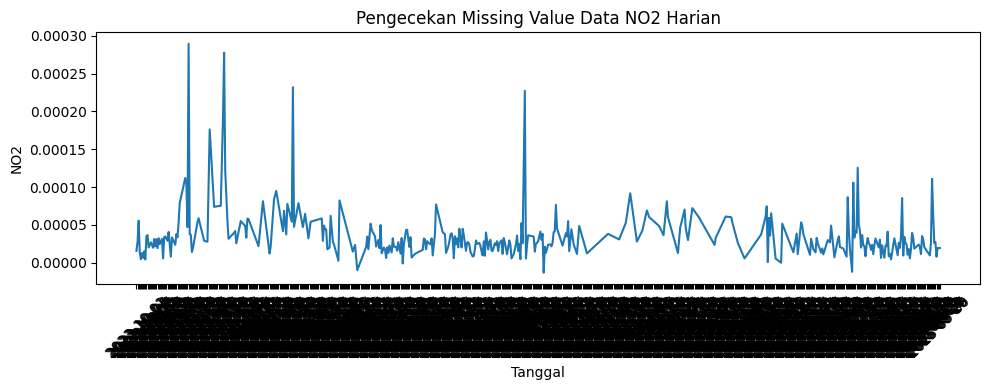

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(df["Date"], df["NO2"])
plt.title("Pengecekan Missing Value Data NO2 Harian")
plt.xlabel("Tanggal")
plt.ylabel("NO2")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Pengecekan missing value dilakukan untuk memastikan tidak terdapat data yang hilang pada hasil agregasi harian NO₂. Proses ini dilakukan menggunakan fungsi isnull() pada dataset CSV. Hasil pengecekan menunjukkan jumlah nilai kosong pada setiap kolom sehingga dapat diketahui apakah diperlukan penanganan lebih lanjut, seperti interpolasi atau imputasi data. Jika hasil pengecekan menunjukkan nilai 0 pada seluruh kolom, maka dataset dinyatakan lengkap dan siap digunakan untuk tahap analisis berikutnya.

In [50]:
#  Deteksi Outlier IQR

import pandas as pd

# Baca data
df = pd.read_csv("NO2_harian.csv")

# Hitung kuartil
Q1 = df["NO2"].quantile(0.25)
Q3 = df["NO2"].quantile(0.75)

# Hitung IQR
IQR = Q3 - Q1

# Batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower Bound :", lower_bound)
print("Upper Bound :", upper_bound)

Q1 : 2.0414585e-05
Q3 : 4.855289e-05
IQR : 2.8138304999999998e-05
Lower Bound : -2.1792872499999997e-05
Upper Bound : 9.07603475e-05


In [51]:
# menampilkan data outer

outliers = df[
    (df["NO2"] < lower_bound) |
    (df["NO2"] > upper_bound)
]

print("Jumlah Outlier:", len(outliers))
print(outliers)

Jumlah Outlier: 23
           Date       NO2
41   2023-11-12  0.000092
42   2023-11-13  0.000099
43   2023-11-14  0.000105
44   2023-11-15  0.000112
45   2023-11-16  0.000105
47   2023-11-18  0.000289
65   2023-12-06  0.000102
66   2023-12-07  0.000176
67   2023-12-08  0.000151
68   2023-12-09  0.000125
69   2023-12-10  0.000099
77   2023-12-18  0.000134
78   2023-12-19  0.000192
79   2023-12-20  0.000278
80   2023-12-21  0.000122
126  2024-02-06  0.000095
141  2024-02-21  0.000232
349  2024-09-18  0.000127
350  2024-09-19  0.000227
445  2024-12-23  0.000092
646  2025-07-14  0.000106
650  2025-07-18  0.000126
717  2025-09-23  0.000111


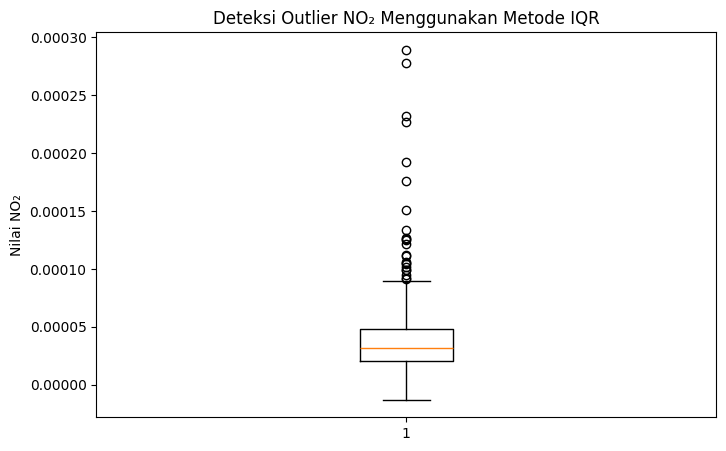

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Baca data
df = pd.read_csv("NO2_harian.csv")

# Buat boxplot
plt.figure(figsize=(8,5))
plt.boxplot(df["NO2"])

plt.title("Deteksi Outlier NO₂ Menggunakan Metode IQR")
plt.ylabel("Nilai NO₂")

plt.show()

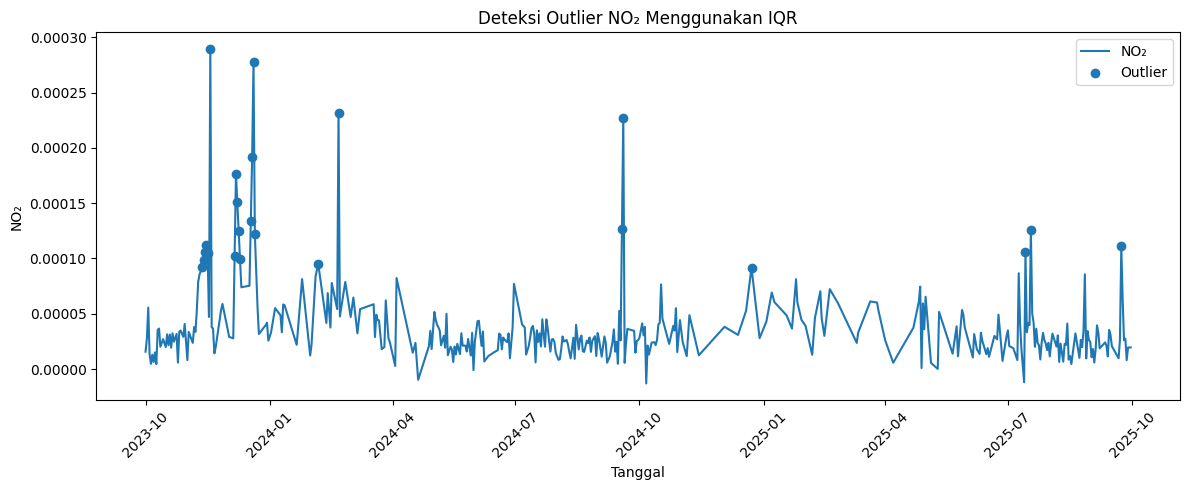

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Baca data
df = pd.read_csv("NO2_harian.csv")

# Hitung IQR
Q1 = df["NO2"].quantile(0.25)
Q3 = df["NO2"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Tandai outlier
df["Outlier"] = (
    (df["NO2"] < lower_bound) |
    (df["NO2"] > upper_bound)
)

# Ubah tanggal
df["Date"] = pd.to_datetime(df["Date"])

# Plot
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["NO2"], label="NO₂")

plt.scatter(
    df[df["Outlier"]]["Date"],
    df[df["Outlier"]]["NO2"],
    label="Outlier"
)

plt.title("Deteksi Outlier NO₂ Menggunakan IQR")
plt.xlabel("Tanggal")
plt.ylabel("NO₂")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()